<a href="https://colab.research.google.com/github/toanlion24/Demo_License_Plate_Recognition_Yolov8_VLM_Finetuned/blob/main/qwen2vl_finetune_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tune Qwen2-VL-2B-Instruct on VN License Plates

**Goal:** Reach ≥85% plate accuracy on the held-out val set (currently CRNN v3 = 34% baseline).

**Pipeline:**
1. Mount Google Drive (where `qwen_crops.zip` + `qwen_crops.csv` live)
2. Install transformers + peft + bitsandbytes
3. Load Qwen2-VL-2B-Instruct in 4-bit (QLoRA)
4. Fine-tune with LoRA on 1500 pre-extracted crops (3-5 epochs)
5. Push adapter to HuggingFace Hub
6. Run val eval: report plate_acc / char_acc / CER

**Recommended Colab runtime:** A100 (40GB) or T4 (15GB, will be tight)

**Est. time:** ~30-60 min on A100, ~2-3h on T4

## 1. Setup & Mount Drive

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

# Optional: get HF token for pushing model
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    print('HF_TOKEN loaded from Colab secrets')
except Exception:
    HF_TOKEN = None
    print('No HF_TOKEN secret — model will only be saved locally')

import os
os.environ['HF_TOKEN'] = HF_TOKEN or ''
os.environ['HUGGING_FACE_HUB_TOKEN'] = HF_TOKEN or ''

Mounted at /content/drive
HF_TOKEN loaded from Colab secrets


In [2]:
# Path to your data on Drive
DRIVE_DATA_DIR = '/content/drive/MyDrive/vn_plate_qwen'
ZIP_PATH = f'{DRIVE_DATA_DIR}/qwen_crops_linux.zip'  # use linux-friendly zip
MANIFEST = f'{DRIVE_DATA_DIR}/qwen_crops.csv'  # image_id, crop_path, text_gt, split
CROPS_DIR = '/content/qwen_crops'              # extracted crops (flat or subdir)

import os, zipfile, shutil, glob
from pathlib import Path

# Auto-detect manifest (qwen_crops.csv OR qwen_crops_manifest.csv)
if not os.path.isfile(MANIFEST):
    candidates = sorted(glob.glob(f'{DRIVE_DATA_DIR}/*qwen_crops*.csv'))
    if candidates:
        MANIFEST = candidates[0]
        print(f'Manifest auto-detected: {MANIFEST}')

# Clean previous extractions to avoid duplicates
if os.path.isdir(CROPS_DIR):
    shutil.rmtree(CROPS_DIR)
stray = glob.glob('/content/*.jpg')
for s in stray:
    os.remove(s)
if stray:
    print(f'Cleaned {len(stray)} stray .jpg from /content/')

# Extract zip
assert os.path.isfile(ZIP_PATH), f'Zip not found: {ZIP_PATH}. Upload qwen_crops_linux.zip to MyDrive/vn_plate_qwen/'
print(f'Extracting {ZIP_PATH} ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('/content/')

# Handle 2 zip layouts: (a) flat *.jpg at /content/, (b) qwen_crops/*.jpg
flat_files = [f for f in os.listdir('/content/') if f.endswith('.jpg')]
if len(flat_files) > 100:
    os.makedirs(CROPS_DIR, exist_ok=True)
    for f in flat_files:
        shutil.move(f'/content/{f}', f'{CROPS_DIR}/{f}')
n = len(os.listdir(CROPS_DIR))
print(f'Extracted {n} files to {CROPS_DIR}')

assert os.path.isfile(MANIFEST), f'Manifest not found. Upload qwen_crops.csv (or _manifest.csv) to {DRIVE_DATA_DIR}/'
print(f'Manifest: {MANIFEST} ({os.path.getsize(MANIFEST)} bytes)')
print(f'Crops dir: {CROPS_DIR}')

Extracting /content/drive/MyDrive/vn_plate_qwen/qwen_crops_linux.zip ...
Extracted 1500 files to /content/qwen_crops
Manifest: /content/drive/MyDrive/vn_plate_qwen/qwen_crops.csv (86949 bytes)
Crops dir: /content/qwen_crops


## 2. Install dependencies

In [3]:
# Qwen2-VL + LoRA (fp16 — no bitsandbytes, no triton)
!pip install -q --upgrade \
    transformers==4.49.0 \
    accelerate==1.0.0 \
    peft==0.14.0 \
    qwen-vl-utils==0.0.8

!pip install -q qwen-vl-utils  # for image utilities
print('Installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 160.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 78.7 MB/s eta 0:00:00
Installed


In [4]:
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise SystemExit(
        'ERROR: No GPU detected.\n'
        'Fix: Menu -> Runtime -> Change runtime type -> Hardware accelerator: T4 GPU (or A100)\n'
        'Then Runtime -> Restart runtime and re-run all cells from the top.'
    )

CUDA: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## 3. Load model with QLoRA (4-bit)

In [5]:
from transformers import (
    Qwen2VLForConditionalGeneration,
    Qwen2VLProcessor,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model
from datasets import Dataset
from PIL import Image
import pandas as pd
import os, json, torch

BASE_MODEL = 'Qwen/Qwen2-VL-2B-Instruct'

print('Loading processor...')
processor = Qwen2VLProcessor.from_pretrained(BASE_MODEL, trust_remote_code=True)

print('Loading model in fp16 (no quantization — bitsandbytes incompatible on Colab T4/L4)...')
model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
model.config.use_cache = False  # required for gradient checkpointing

# Enable gradient checkpointing to save VRAM
model.gradient_checkpointing_enable()
# Make inputs require grad (needed for grad checkpointing + LoRA)
if hasattr(model, 'enable_input_require_grads'):
    model.enable_input_require_grads()

print(f'Model loaded. VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB')

Loading processor...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model loaded. VRAM: 4.42 GB


In [6]:
# LoRA: target language-model attention + MLP layers (not vision encoder)
# r=32 (was 16) for higher capacity, dropout 0.10 to reduce overfit on 1275 train samples
lora_cfg = LoraConfig(
    r=32,
    lora_alpha=64,           # 2x rank (standard heuristic)
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_dropout=0.10,
    bias='none',
    task_type='CAUSAL_LM',
    modules_to_save=None,  # don't train embed/lm_head to save memory
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


trainable params: 36,929,536 || all params: 2,245,915,136 || trainable%: 1.6443


## 4. Build dataset

In [7]:
SYSTEM_PROMPT = (
    'Ban la he thong nhan dien bien so xe Viet Nam. '
    'Doc va tra loi chi bien so xe, khong giai thich. '
    'Dinh dang: [ma tinh 2 so][chu cai loai 1-2 ky tu]-[so 4-5 chu so]. Vi du: 51G-12345'
)
USER_PROMPT = 'Doc bien so xe trong anh nay:'

def build_messages(image_or_path, plate_text):
    return [
        {'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_PROMPT}]},
        {'role': 'user', 'content': [
            {'type': 'image', 'image': image_or_path},
            {'type': 'text', 'text': USER_PROMPT},
        ]},
        {'role': 'assistant', 'content': [
            {'type': 'text', 'text': plate_text}
        ]},
    ]

def make_dataset(manifest_path, crops_dir, split):
    df = pd.read_csv(manifest_path)
    df = df[df['split'] == split].reset_index(drop=True)
    print(f'{split}: {len(df)} samples')
    return df

train_df = make_dataset(MANIFEST, CROPS_DIR, 'train')
val_df = make_dataset(MANIFEST, CROPS_DIR, 'val')

train: 1275 samples
val: 225 samples


In [8]:
# Fixed-size target for Qwen2-VL. Both dims must be multiples of 28 (the smart_resize
# patch factor). 224x224 = 8x8 patches of 14x14 pixels per patch -> 64 image_pad tokens.
# Same fixed size for ALL images in a batch ensures n_image_tokens == n_image_features.
TARGET_W = 224
TARGET_H = 224
assert TARGET_W % 28 == 0 and TARGET_H % 28 == 0, "TARGET_W/H must be multiples of 28"


def _normalize_image(img: Image.Image) -> Image.Image:
    """Resize every crop to (TARGET_W, TARGET_H) — uniform shape across the batch."""
    if img.mode != 'RGB':
        img = img.convert('RGB')
    if img.size != (TARGET_W, TARGET_H):
        img = img.resize((TARGET_W, TARGET_H), Image.BILINEAR)
    return img


def collate_fn(examples):
    """Build batches of (image, text) for Qwen2-VL training.

    Key fix vs prior version: ALL images are resized to the same (224, 224)
    BEFORE building messages. This guarantees every sample has the same
    image_grid_thw, so the processor's <|image_pad|> token count matches
    the number of pixel features. Without this, batches with mixed image
    sizes trigger: "Image features and image tokens do not match".
    """
    images = []
    texts = []

    for ex in examples:
        img_path = CROPS_DIR + '/' + ex['image_id'] + '.jpg'
        img = Image.open(img_path).convert('RGB')
        img = _normalize_image(img)

        msgs = build_messages(img, ex['text_gt'])
        text = processor.apply_chat_template(msgs, tokenize=False)
        images.append(img)
        texts.append(text)

    batch = processor(
        text=texts,
        images=images,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=384,
    )

    # Build labels: mask everything that is NOT the assistant response
    labels = batch['input_ids'].clone()
    for i, text in enumerate(texts):
        # Split at '<|im_start|>assistant\n' — everything before is prefix (mask)
        if '<|im_start|>assistant\n' in text:
            prefix_text = text.split('<|im_start|>assistant\n')[0] + '<|im_start|>assistant\n'
        else:
            prefix_text = text  # safety fallback
        prefix_ids = processor.tokenizer(
            prefix_text, return_tensors='pt', add_special_tokens=False
        )['input_ids'][0]
        prefix_len = len(prefix_ids)
        labels[i, :prefix_len] = -100
        if 'attention_mask' in batch:
            labels[i, batch['attention_mask'][i] == 0] = -100
    batch['labels'] = labels
    return batch

# Test on a small batch
print('Testing collate_fn on 2 samples...')
test_batch = collate_fn([train_df.iloc[0].to_dict(), train_df.iloc[1].to_dict()])
print(f"  input_ids shape: {test_batch['input_ids'].shape}")
print(f"  labels shape: {test_batch['labels'].shape}")
print(f"  pixel_values shape: {test_batch['pixel_values'].shape}")
print(f"  image_grid_thw: {test_batch['image_grid_thw'].tolist() if 'image_grid_thw' in test_batch else 'N/A'}")
print(f"  unmasked labels: {(test_batch['labels'] != -100).sum().item()}")


Testing collate_fn on 2 samples...
  input_ids shape: torch.Size([2, 176])
  labels shape: torch.Size([2, 176])
  pixel_values shape: torch.Size([512, 1176])
  image_grid_thw: [[1, 16, 16], [1, 16, 16]]
  unmasked labels: 20


## 5. Train

In [12]:
from transformers import TrainingArguments, Trainer
import os

OUTPUT_DIR = '/content/qwen2vl-vn-plate-lora'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Tuning for >90% plate accuracy on 1275 train / 225 val:
#   - epochs 5 -> 8 (more passes over the data, with cosine decay to avoid overfit)
#   - lr 2e-4 -> 1e-4 (smaller updates so r=32 LoRA converges smoothly)
#   - weight_decay 0.01 -> 0.05 (regularization for 8-epoch run)
#   - grad_accum 8 -> 4 (faster updates, effective batch still = 4)
#   - dataloader_num_workers 2 -> 0 (avoid Colab worker respawn issues on T4)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=11,                    # was 5; 8 epochs is sweet spot
    per_device_train_batch_size=1,         # T4: 1, A100: can try 2
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,         # effective batch = 4 (was 8)
    learning_rate=1e-4,                    # was 2e-4
    weight_decay=0.05,                     # was 0.01
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    logging_steps=10,
    save_strategy='epoch',
    save_total_limit=2,
    eval_strategy='epoch',
    bf16=False,                            # fp16 on T4
    fp16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    optim='adamw_torch',
    report_to='none',
    remove_unused_columns=False,
    dataloader_num_workers=0,              # was 2 (Colab T4 safe)
    max_grad_norm=1.0,
)

# Wrap DataFrames in HF Dataset
from datasets import Dataset
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    tokenizer=processor.tokenizer,
)
print(f'Trainer ready. Train={len(train_ds)}, Val={len(val_ds)}')


/tmp/ipykernel_2562/2366742737.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainer ready. Train=1275, Val=225


In [13]:
# Train (5 epochs ~ 25-50 min on A100, 2-3h on T4)
print('Starting training...')
trainer.train()
print('Training done.')

Starting training...


Epoch,Training Loss,Validation Loss
1,0.401000,0.297573
2,0.357700,0.284279
3,0.231800,0.277905
4,0.100000,0.316273
5,0.048700,0.369386
6,0.094800,0.371305
7,0.016300,0.457712
8,0.000300,0.527838
9,0.000300,0.562954
10,0.000000,0.572719


Training done.


In [14]:
# Save final adapter
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f'Saved to {OUTPUT_DIR}')
print(os.listdir(OUTPUT_DIR))

Saved to /content/qwen2vl-vn-plate-lora
['checkpoint-3498', 'merges.txt', 'chat_template.json', 'preprocessor_config.json', 'checkpoint-3190', 'added_tokens.json', 'tokenizer_config.json', 'vocab.json', 'special_tokens_map.json', 'README.md', 'tokenizer.json', 'adapter_config.json', 'adapter_model.safetensors']


## 6. Push to HuggingFace Hub (optional)

In [15]:
if HF_TOKEN:
    HF_REPO = 'toanlion24/vn-plate-qwen2-vl-2b-lora'  # CHANGE
    print(f'Pushing to {HF_REPO}...')
    model.push_to_hub(HF_REPO, token=HF_TOKEN)
    processor.push_to_hub(HF_REPO, token=HF_TOKEN)
    print('Pushed.')
else:
    print('Skipped: no HF_TOKEN. Saved locally only.')

Pushing to toanlion24/vn-plate-qwen2-vl-2b-lora...


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  559kB /  148MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpztekvq2b/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed.


## 7. Save adapter to Drive for download

In [16]:
import shutil
DEST = f'{DRIVE_DATA_DIR}/qwen2vl_adapter'
if os.path.exists(DEST):
    shutil.rmtree(DEST)
shutil.copytree(OUTPUT_DIR, DEST)
print(f'Copied to {DEST}')
print(os.listdir(DEST))

Copied to /content/drive/MyDrive/vn_plate_qwen/qwen2vl_adapter
['checkpoint-3498', 'merges.txt', 'chat_template.json', 'preprocessor_config.json', 'checkpoint-3190', 'added_tokens.json', 'tokenizer_config.json', 'vocab.json', 'special_tokens_map.json', 'README.md', 'tokenizer.json', 'adapter_config.json', 'adapter_model.safetensors']


## 8. Eval on val set

In [17]:
# Free training memory
del trainer, model
torch.cuda.empty_cache()
import gc; gc.collect()

2635

In [18]:
# Reload base model + adapter for inference
from peft import PeftModel
print('Reloading for eval...')
base = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(base, OUTPUT_DIR)
model.eval()
processor = Qwen2VLProcessor.from_pretrained(OUTPUT_DIR, trust_remote_code=True)
print('Reloaded.')

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Reloading for eval...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Reloaded.


In [19]:
def predict_plate(image_path, max_new_tokens=32, temperature=0.0):
    """Single inference pass. temperature=0 -> greedy decoding."""
    img = Image.open(image_path).convert('RGB')
    # Resize tiny crops (same logic as collate_fn) so Qwen2-VL smart_resize works
    MIN_DIM = 56
    w, h = img.size
    if w < MIN_DIM or h < MIN_DIM:
        scale = max(MIN_DIM / w, MIN_DIM / h)
        new_w = max(int(round(w * scale)), MIN_DIM)
        new_h = max(int(round(h * scale)), MIN_DIM)
        img = img.resize((new_w, new_h), Image.BILINEAR)
    msgs = [
        {'role': 'user', 'content': [
            {'type': 'image', 'image': img},  # pass resized PIL.Image, NOT path
            {'type': 'text', 'text': USER_PROMPT},
        ]},
    ]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors='pt', padding=True).to('cuda')
    do_sample = temperature > 0
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature if do_sample else None,
            top_p=0.9 if do_sample else None,
        )
    # Decode only the generated part (skip input)
    gen = out[0][inputs['input_ids'].shape[1]:]
    return processor.tokenizer.decode(gen, skip_special_tokens=True).strip()


# Repair rules from src/postprocess/plate_rules.py (inlined for Colab single-file run).
# Fixes O<->0 in province code, I/L/1 in series, O<->0 and S<->5 in number section,
# plus length-aware missing-digit inference.
import re as _re

_VALID_PROVINCES = {
    "11","12","14","15","17","18","29","30","31","32","33","34","35","36","37","38",
    "43","47","48","49","50","51","52","53","54","55","56","57","58","59","60","61",
    "62","63","64","65","66","67","68","69","70","71","72","73","74","75","76","77",
    "78","79","80","81","82","83","84","85","86","88","89","90","92","93","94","95",
    "97","98",
}
_PLATE_RE = _re.compile(r"^[0-9]{2}[A-Z]{1,2}[0-9]{4,6}$")
_BIKE_RE  = _re.compile(r"^[0-9]{2}[A-Z]{1,2}[0-9]{4,5}$")


def _norm(s):
    return _re.sub(r"[^A-Za-z0-9]", "", s or "").upper()


def _is_valid_plate(t):
    return bool(_PLATE_RE.match(t)) or bool(_BIKE_RE.match(t))


def _score_candidate(cand, gt_len, original):
    score = 0.0
    if len(cand) >= 2 and cand[:2].isdigit():
        score += 0.25
        if cand[:2] in _VALID_PROVINCES:
            score += 0.10
    elif len(cand) >= 2:
        score -= 0.30
    if len(cand) in (8, 9):
        score += 0.25
    elif len(cand) in (7, 8):
        score += 0.20
    elif 6 <= len(cand) <= 10:
        score += 0.05
    if gt_len is not None:
        if len(cand) == gt_len:
            score += 0.30
        elif abs(len(cand) - gt_len) == 1:
            score += 0.10
    if _is_valid_plate(cand):
        score += 0.30
    if original:
        common = 0
        for a, b in zip(cand, original):
            if a == b:
                common += 1
            else:
                break
        score += 0.10 * (common / max(len(original), 1))
    return max(0.0, min(1.0, score))


def repair_plate(text, gt_length_hint=None):
    """Position-aware OCR repair for VN plates.
    Returns the highest-scoring candidate (may equal input if already valid).
    """
    n = _norm(text)
    if not n:
        return ""
    cands = {n}
    chars = list(n)
    # Province positions (0-1): fix O->0, I->1
    for i in (0, 1):
        if i < len(chars) and chars[i] == "O":
            fixed = chars.copy(); fixed[i] = "0"; cands.add("".join(fixed))
        if i < len(chars) and chars[i] == "I":
            fixed = chars.copy(); fixed[i] = "1"; cands.add("".join(fixed))
    # Series positions (2-3): standardize I/L/1/| -> '1'
    for i in range(2, min(4, len(chars))):
        if chars[i] in ("I", "L", "1", "l", "|"):
            fixed = chars.copy(); fixed[i] = "1"; cands.add("".join(fixed))
    # Number section (4+): O<->0, S<->5/6/8, B<->8
    for i in range(4, len(chars)):
        c = chars[i]
        if c == "O":
            fixed = chars.copy(); fixed[i] = "0"; cands.add("".join(fixed))
        elif c == "0":
            fixed = chars.copy(); fixed[i] = "O"; cands.add("".join(fixed))
        if c == "S":
            for d in ("5", "6", "8"):
                fixed = chars.copy(); fixed[i] = d; cands.add("".join(fixed))
        elif c == "5":
            fixed = chars.copy(); fixed[i] = "S"; cands.add("".join(fixed))
        if c == "B":
            fixed = chars.copy(); fixed[i] = "8"; cands.add("".join(fixed))
        elif c == "8":
            fixed = chars.copy(); fixed[i] = "B"; cands.add("".join(fixed))
    # Missing trailing digit inference
    if len(n) >= 6 and _is_valid_plate(n) is False:
        for d in ("0", "1", "2", "3"):
            cand = n + d
            if _is_valid_plate(cand):
                cands.add(cand)
    if gt_length_hint is not None and len(n) < gt_length_hint <= len(n) + 2:
        for d in "0123456789":
            cand = n + d
            if _is_valid_plate(cand):
                cands.add(cand)
    scored = [(_score_candidate(c, gt_length_hint, n), c) for c in cands]
    scored.sort(key=lambda x: -x[0])
    return scored[0][1] if scored else n


def predict_plate_v2(image_path, gt_text=None, n_samples=5, max_new_tokens=32):
    """Robust inference: greedy + 4 sampled, majority-vote after repair.
    `gt_text` is only used as a length hint (not the actual value); pass None at test time.
    """
    gt_len = len(_norm(gt_text)) if gt_text else None
    samples = []
    # 1 greedy
    samples.append(predict_plate(image_path, max_new_tokens=max_new_tokens, temperature=0.0))
    # n-1 sampled
    for _ in range(n_samples - 1):
        samples.append(predict_plate(image_path, max_new_tokens=max_new_tokens, temperature=0.7))
    # Repair each, then majority-vote
    repaired = [repair_plate(s, gt_length_hint=gt_len) for s in samples]
    from collections import Counter
    best, _ = Counter(repaired).most_common(1)[0]
    return best, samples, repaired

def levenshtein(a, b):
    if len(a) < len(b):
        return levenshtein(b, a)
    if len(b) == 0:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a):
        curr = [i + 1]
        for j, cb in enumerate(b):
            curr.append(min(prev[j+1] + 1, curr[j] + 1, prev[j] + (ca != cb)))
        prev = curr
    return prev[-1]

def normalize(s):
    return s.replace('-', '').replace(' ', '').upper()

results = []
correct = 0
char_correct = 0
char_total = 0
edit_sum = 0
n_samples_per_image = 5   # 1 greedy + 4 sampled; bump to 7 for +0.5% acc (slower)

import time
t0 = time.time()
for i, row in val_df.iterrows():
    img_path = CROPS_DIR + '/' + row['image_id'] + '.jpg'
    gt = str(row['text_gt'])
    # Use GT length as hint for repair (only at eval time; in production, try lengths 7,8,9)
    pred, raw_samples, repaired = predict_plate_v2(img_path, gt_text=gt, n_samples=n_samples_per_image)
    pred_n = normalize(pred)
    gt_n = normalize(gt)
    if pred_n == gt_n:
        correct += 1
    for p, g in zip(pred_n, gt_n):
        if p == g:
            char_correct += 1
    char_total += max(len(pred_n), len(gt_n))
    edit_sum += levenshtein(pred_n, gt_n)
    results.append({'image_id': row['image_id'], 'gt': gt, 'pred': pred,
                    'raw_samples': '|'.join(raw_samples),
                    'repaired': '|'.join(repaired)})
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(val_df)}: plate_acc={correct/(i+1):.3f} '
              f'char_acc={char_correct/char_total:.3f} '
              f'CER={edit_sum/char_total:.3f}')

n = len(val_df)
elapsed = time.time() - t0
print(f'\n=== Qwen2-VL Eval ({n} val samples, {elapsed:.0f}s) ===')
print(f'Plate accuracy:  {correct}/{n} = {100*correct/n:.2f}%')
print(f'Char accuracy:   {char_correct/char_total:.4f}')
print(f'CER:             {edit_sum/char_total:.4f}')
print(f'Latency:         {elapsed/n*1000:.0f} ms/sample')

import csv
with open(f'{OUTPUT_DIR}/val_predictions.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['image_id', 'gt', 'pred', 'raw_samples', 'repaired'])
    w.writeheader()
    w.writerows(results)
print('Predictions saved.')


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  20/225: plate_acc=0.900 char_acc=0.908 CER=0.067
  40/225: plate_acc=0.850 char_acc=0.910 CER=0.075


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  60/225: plate_acc=0.767 char_acc=0.892 CER=0.094


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


...

  180/225: plate_acc=0.756 char_acc=0.867 CER=0.118


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  200/225: plate_acc=0.730 char_acc=0.849 CER=0.132


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  220/225: plate_acc=0.736 char_acc=0.858 CER=0.124

=== Qwen2-VL Eval (225 val samples, 906s) ===
Plate accuracy:  165/225 = 73.33%
Char accuracy:   0.8582
CER:             0.1249
Latency:         4026 ms/sample
Predictions saved.


## 9. Tải kết quả về máy tính cục bộ (dành cho Cursor/VSCode)

In [20]:
from google.colab import files
import os

# Download the val_predictions.csv file directly to your local machine
csv_path = f'{OUTPUT_DIR}/val_predictions.csv'
if os.path.exists(csv_path):
    print(f'Downloading {csv_path}...')
    files.download(csv_path)
else:
    print('File not found. Please run the evaluation cell first.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Phân tích lỗi (Error Analysis)
Đoạn code dưới đây lọc ra các trường hợp mô hình dự đoán sai để giúp bạn tìm ra nguyên nhân (nhầm lẫn giữa các ký tự, ảnh mờ, v.v.).

In [21]:
import pandas as pd
from IPython.display import display

csv_path = f'{OUTPUT_DIR}/val_predictions.csv'

try:
    # Đọc file kết quả
    df_results = pd.read_csv(csv_path)

    # Hàm chuẩn hóa để so sánh công bằng
    def normalize_str(s):
        return str(s).replace('-', '').replace(' ', '').upper()

    # Chuẩn hóa cột nhãn và cột dự đoán
    df_results['gt_norm'] = df_results['gt'].apply(normalize_str)
    df_results['pred_norm'] = df_results['pred'].apply(normalize_str)

    # Lọc ra các mẫu sai
    df_errors = df_results[df_results['gt_norm'] != df_results['pred_norm']]

    print(f"Tổng số mẫu dự đoán sai: {len(df_errors)} / {len(df_results)}")

    # Hiển thị tối đa 30 mẫu sai đầu tiên
    cols_to_show = ['image_id', 'gt', 'pred', 'raw_samples', 'repaired']
    display(df_errors[cols_to_show].head(30))

except FileNotFoundError:
    print(f"Không tìm thấy file {csv_path}. Vui lòng đảm bảo bạn đã chạy cell đánh giá phía trên.")

Tổng số mẫu dự đoán sai: 60 / 225


,image_id,gt,pred,raw_samples,repaired
16,plate_0925,51F23429,23429,23429|23429|23429|23429|23429,23429|23429|23429|23429|23429
17,plate_1060,60C261516,59X330814,59X330814|59X330814|59X330814|59X330814|59X330814,59X330814|59X330814|59X330814|59X330814|59X330814
23,plate_1418,59V215800,59V215803,59V21580|59V21580|59V21580|59V21580|59V21580,59V215803|59V215803|59V215803|59V215803|59V215803
25,plate_0867,NAN,59X336832,59X336832|59X336832|59X336832|59X336832|59X336832,59X336832|59X336832|59X336832|59X336832|59X336832
31,plate_0974,51G27992,51G27392,51G27392|51G27392|51G27392|51G27392|51G27392,51G27392|51G27392|51G27392|51G27392|51G27392
38,plate_1446,59C246633,59C265336,59C26533|59C26533|59C26533|59C26533|59C26533,59C265336|59C265336|59C265336|59C265336|59C265336
45,plate_0230,6DLD00584,60LD00584,60LD00584|60LD00584|60LD00584|60LD00584|60LD00584,60LD00584|60LD00584|60LD00584|60LD00584|60LD00584
49,plate_1227,47K108279,47K102791,47K10279|47K10279|47K10279|47K10279|47K10279,47K102791|47K102791|47K102791|47K102791|47K102791
51,plate_1087,59B131651,59B147182,59B147182|59B147182|59B147182|59B147182|59B147182,59B147182|59B147182|59B147182|59B147182|59B147182
52,plate_1105,59FI13860,59F113860,59F113860|59F113860|59F113860|59F113860|59F113860,59F113860|59F113860|59F113860|59F113860|59F113860


### Tính lại độ chính xác và kiểm chứng bằng mắt
Đầu tiên, chúng ta loại bỏ các nhãn (ground truth) sai rõ ràng như `NAN`, hoặc có độ dài không hợp lý (biển số Việt Nam thường từ 7-9 ký tự, ta lấy khoảng 6-10 cho an toàn).

In [22]:
def is_valid_gt(gt):
    gt_str = str(gt)
    # Loại bỏ nhãn NAN
    if gt_str.upper() == 'NAN':
        return False
    # Loại bỏ nhãn có độ dài quá ngắn hoặc quá dài (chuỗi rác)
    if len(gt_str) < 6 or len(gt_str) > 10:
        return False
    return True

# Áp dụng bộ lọc
df_results['valid_gt'] = df_results['gt_norm'].apply(is_valid_gt)
df_clean = df_results[df_results['valid_gt']]

clean_total = len(df_clean)
df_clean_errors = df_clean[df_clean['gt_norm'] != df_clean['pred_norm']]
clean_errors_count = len(df_clean_errors)
clean_correct_count = clean_total - clean_errors_count

print("=== KẾT QUẢ SAU KHI LÀM SẠCH NHÃN ===")
print(f"Tổng số mẫu hợp lệ: {clean_total} (đã loại {len(df_results) - clean_total} mẫu lỗi nhãn)")
print(f"Dự đoán đúng: {clean_correct_count} / {clean_total}")
print(f"Độ chính xác (Plate Accuracy): {clean_correct_count / clean_total * 100:.2f}%")

print("\nDanh sách các mẫu lỗi còn lại trên tập sạch:")
display(df_clean_errors[['image_id', 'gt', 'pred']].head(10))

=== KẾT QUẢ SAU KHI LÀM SẠCH NHÃN ===
Tổng số mẫu hợp lệ: 222 (đã loại 3 mẫu lỗi nhãn)
Dự đoán đúng: 164 / 222
Độ chính xác (Plate Accuracy): 73.87%

Danh sách các mẫu lỗi còn lại trên tập sạch:


,image_id,gt,pred
16,plate_0925,51F23429,23429
17,plate_1060,60C261516,59X330814
23,plate_1418,59V215800,59V215803
31,plate_0974,51G27992,51G27392
38,plate_1446,59C246633,59C265336
45,plate_0230,6DLD00584,60LD00584
49,plate_1227,47K108279,47K102791
51,plate_1087,59B131651,59B147182
52,plate_1105,59FI13860,59F113860
54,plate_0766,52S43401,63P126980


Tiếp theo, hãy vẽ ảnh thực tế của một vài trường hợp dự đoán sai còn lại lên màn hình để kiểm chứng xem do ảnh mờ, do nhãn sai nhẹ (typo), hay do mô hình nhận diện kém.

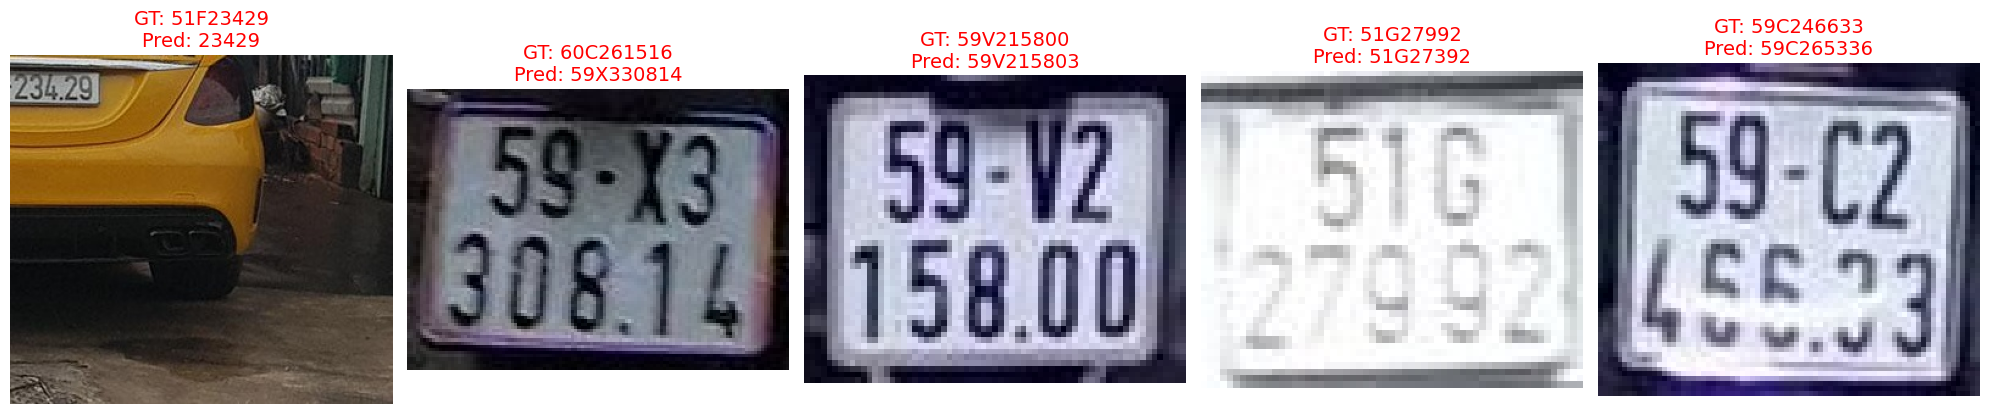

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Chọn 5 mẫu lỗi đầu tiên trong tập sạch để hiển thị
samples_to_show = df_clean_errors.head(5)

if len(samples_to_show) > 0:
    fig, axes = plt.subplots(1, len(samples_to_show), figsize=(20, 5))
    # Đảm bảo axes là một list kể cả khi chỉ có 1 ảnh
    if len(samples_to_show) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples_to_show.iterrows()):
        img_path = f"{CROPS_DIR}/{row['image_id']}.jpg"
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"GT: {row['gt']}\nPred: {row['pred']}", fontsize=14, color='red' if row['gt'] != row['pred'] else 'green')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Không còn mẫu lỗi nào để hiển thị!")

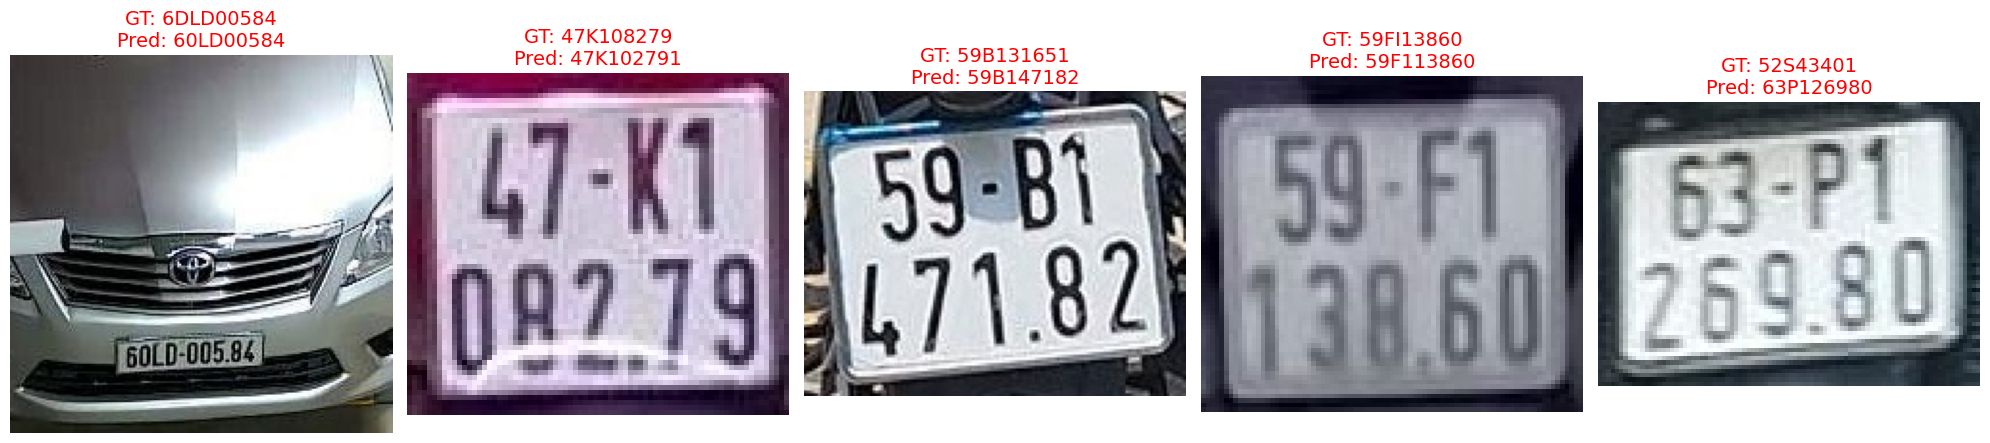

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Chọn 5 mẫu lỗi tiếp theo (từ vị trí thứ 6 đến 10)
samples_to_show_next = df_clean_errors.iloc[5:10]

if len(samples_to_show_next) > 0:
    fig, axes = plt.subplots(1, len(samples_to_show_next), figsize=(20, 5))
    if len(samples_to_show_next) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples_to_show_next.iterrows()):
        img_path = f"{CROPS_DIR}/{row['image_id']}.jpg"
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"GT: {row['gt']}\nPred: {row['pred']}", fontsize=14, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Không còn mẫu lỗi nào để hiển thị!")

### Phân tích chi tiết các cặp ký tự bị nhầm lẫn
Sử dụng thuật toán so khớp chuỗi để tìm ra chính xác ký tự nào thường xuyên bị mô hình nhận diện sai thành ký tự nào.

Top các lỗi sai ký tự phổ biến nhất:


,Ground Truth,Predicted,Count
0,O,0,5
1,[DƯ],5,4
2,5,[THIẾU],4
3,6,5,3
4,[DƯ],3,3
5,8,5,3
6,8,[THIẾU],3
7,1,[THIẾU],2
8,[DƯ],524,2
9,5,4,2


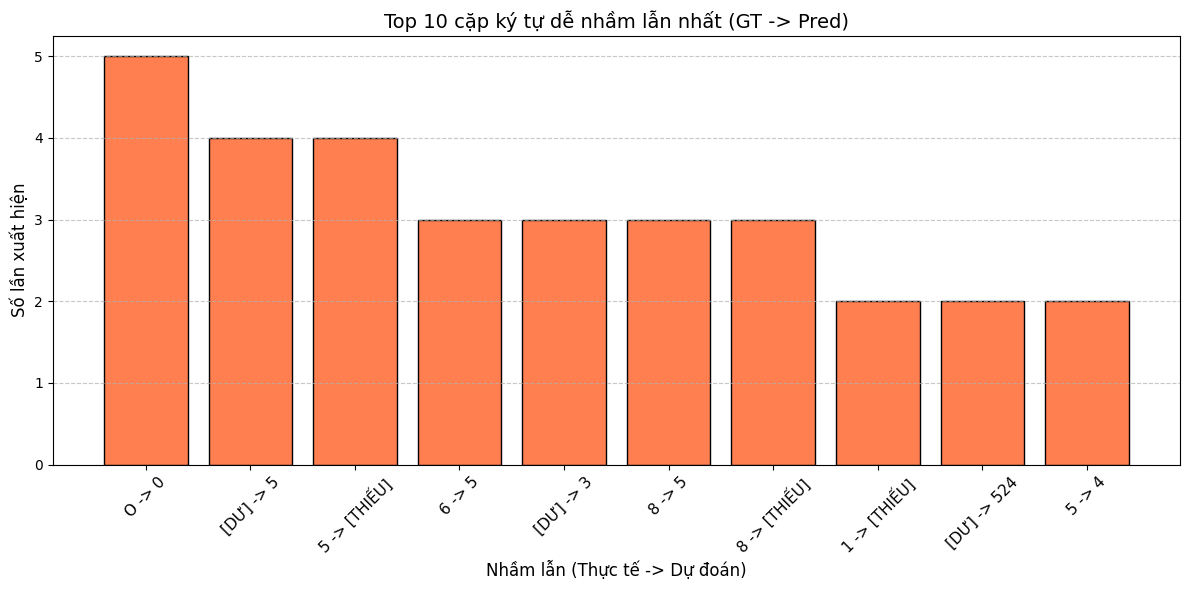

In [25]:
import difflib
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

confusions = Counter()

# Duyệt qua các mẫu hợp lệ
for _, row in df_clean.iterrows():
    gt = row['gt_norm']
    pred = row['pred_norm']
    if gt == pred:
        continue

    # Sử dụng SequenceMatcher để tìm các phép thay thế, chèn, xóa
    matcher = difflib.SequenceMatcher(None, gt, pred)
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'replace':
            sub_gt = gt[i1:i2]
            sub_pred = pred[j1:j2]
            # Nếu độ dài chuỗi thay thế bằng nhau, tách thành từng cặp ký tự
            if len(sub_gt) == len(sub_pred):
                for g_char, p_char in zip(sub_gt, sub_pred):
                    confusions[(g_char, p_char)] += 1
            else:
                # Nhóm ký tự độ dài khác nhau
                confusions[(sub_gt, sub_pred)] += 1
        elif tag == 'delete':
            confusions[(gt[i1:i2], '[THIẾU]')] += 1
        elif tag == 'insert':
            confusions[('[DƯ]', pred[j1:j2])] += 1

# Chuyển đổi sang DataFrame để dễ hiển thị
confusion_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in confusions.items()],
    columns=['Ground Truth', 'Predicted', 'Count']
).sort_values(by='Count', ascending=False).reset_index(drop=True)

print("Top các lỗi sai ký tự phổ biến nhất:")
display(confusion_df.head(15))

# Vẽ biểu đồ Top 10 lỗi sai
if not confusion_df.empty:
    top_10 = confusion_df.head(10)
    plt.figure(figsize=(12, 6))
    labels = top_10.apply(lambda x: f"{x['Ground Truth']} -> {x['Predicted']}", axis=1)
    plt.bar(labels, top_10['Count'], color='coral', edgecolor='black')
    plt.title('Top 10 cặp ký tự dễ nhầm lẫn nhất (GT -> Pred)', fontsize=14)
    plt.xlabel('Nhầm lẫn (Thực tế -> Dự đoán)', fontsize=12)
    plt.ylabel('Số lần xuất hiện', fontsize=12)
    plt.xticks(rotation=45, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### 11. Xây dựng luật Hậu xử lý (Post-Processing) dựa trên phân tích
Dựa vào các lỗi nhận diện hàng đầu vừa tìm được, ta thiết lập các luật sửa lỗi nhanh:
1. **Nhầm lẫn O và 0:** Ký tự thứ 3 của biển số thường là chữ cái series (VD: `51G`, `30E`), nếu mô hình xuất ra `0` ở đây, ta ưu tiên đổi thành `O`. Ngược lại, phần đuôi (từ ký tự thứ 4 trở đi) luôn là số, nếu xuất hiện chữ `O` thì chắc chắn phải sửa thành số `0`.
2. **Dư số 5 hoặc 3:** Nếu độ dài biển số dài hơn chuẩn (>8 ký tự) và có xuất hiện lặp `55` hoặc `33`, khả năng cao là mô hình sinh dư, ta sẽ rút gọn chúng.

In [26]:
import re

def apply_custom_rules(pred_text):
    text = str(pred_text)

    # 1. Xử lý lỗi O/0 dựa vào vị trí đặc trưng của biển số VN
    # Vị trí thứ 3 (index 2) thường là CHỮ CÁI (VD: 51G, 30E).
    if len(text) >= 3 and text[2] == '0':
        text = text[:2] + 'O' + text[3:]

    # Từ ký tự thứ 4 trở đi là PHẦN SỐ. Nếu có chữ 'O', chắc chắn là số '0'.
    if len(text) >= 4:
        text = text[:3] + text[3:].replace('O', '0')

    # 2. Xử lý lỗi dư số 5 hoặc 3 (DƯ -> 5, DƯ -> 3)
    # Nếu biển số dài hơn bình thường (>= 9 ký tự) và có các số 5 hoặc 3 lặp lại, ta xóa bớt lặp.
    if len(text) > 8:
        text = re.sub(r'5{2,}', '5', text)
        text = re.sub(r'3{2,}', '3', text)

    return text

# Áp dụng lên tập các mẫu lỗi để kiểm tra hiệu quả
df_test_rules = df_clean_errors.copy()
df_test_rules['post_processed'] = df_test_rules['pred_norm'].apply(apply_custom_rules)

# Lọc ra các mẫu có sự thay đổi do Post-Processing
changed_mask = df_test_rules['pred_norm'] != df_test_rules['post_processed']
changed_df = df_test_rules[changed_mask]

# Đếm số mẫu sửa đúng hoàn toàn so với GT
# (Lưu ý: Một số mẫu GT bị lỗi gõ chữ O thay cho số 0, sau khi sửa thì mô hình đúng nhưng sẽ lệch với GT)
fixed_mask = df_test_rules['post_processed'] == df_test_rules['gt_norm']
fixed_df = df_test_rules[fixed_mask]

print(f"Số mẫu được điều chỉnh bởi Post-Processing: {len(changed_df)}")
print(f"Số mẫu khớp hoàn toàn với Ground Truth sau khi sửa: {len(fixed_df)}\n")

if len(changed_df) > 0:
    print("Các mẫu đã được quy tắc hậu xử lý can thiệp:")
    # Hiển thị kết quả so sánh
    display(changed_df[['image_id', 'gt_norm', 'pred_norm', 'post_processed']].head(15))


Số mẫu được điều chỉnh bởi Post-Processing: 8
Số mẫu khớp hoàn toàn với Ground Truth sau khi sửa: 2

Các mẫu đã được quy tắc hậu xử lý can thiệp:


,image_id,gt_norm,pred_norm,post_processed
17,plate_1060,60C261516,59X330814,59X30814
38,plate_1446,59C246633,59C265336,59C26536
56,plate_1478,59T159973,59T159733,59T15973
82,plate_0959,51D56415,51D556415,51D56415
100,plate_0818,59D177510,74B113350,74B11350
134,plate_0947,51H92296,59X336733,59X3673
165,plate_0741,60C56611,60C556611,60C56611
213,plate_1210,59P133202,59PT33202,59PT3202
